# Heat budget for CESM2-LENS (iteration 0)

In [1]:
import xarray as xr

In [3]:
filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1, ensemble_member=ens_memb_index).sel(time=slice('1979-01', '2020-12')).compute()

In [ ]:
heat_budget

## Import statements

In [94]:
import pickle
import cmocean
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import dask
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw
import json 
from IPython.utils import io
from os.path import exists
from scipy.stats import gaussian_kde
import seaborn as sns
import netCDF4 as nc4

import warnings
warnings.filterwarnings("ignore")

## Functions

In [95]:
def pop_find_lat_ind(loc, LATDAT): # from Anna's notebook
    return np.abs(LATDAT[:, 0].values - loc).argmin()

In [96]:
def pop_find_lon_ind(loc, LONDAT, direction="w"): # from Anna's notebook
    if direction.lower() in ["east", "e"]:
        value = loc
    elif direction.lower() in ["west", "w"]:
        value = 360 - loc
    else:
        print("I do not know which direction.")
    return np.nanargmin(np.abs(LONDAT[0, :].values - value))

In [97]:
# Accessing glade CESM LENS2
def get_var_paths(directory, var):
    # Prefixes to match for future and historical datasets
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']

    # Sets to store unique prefixes for future and historical filenames
    prefixes_fut = list()
    prefixes_hist = list()

    # Iterate through files in the directory
    for filename in os.listdir(directory):
        # Check and add prefixes for future scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])

        # Check and add prefixes for historical scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])

    prefixes_hist_set = set(prefixes_hist)
    sorted_unique_list_hist = sorted(prefixes_hist_set)

    prefixes_fut_set = set(prefixes_fut)
    sorted_unique_list_fut = sorted(prefixes_fut_set)

    path_intermed_fut = sorted_unique_list_fut
    path_intermed_hist = sorted_unique_list_hist

    return path_intermed_hist, path_intermed_fut

In [98]:
def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var,directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    ds_var_fut = file_path_to_var_ds(fut_file_paths)
    ds_var_hist = file_path_to_var_ds(hist_file_paths)
    return ds_var_hist, ds_var_fut


In [99]:
def find_identifier_with_index(prefixes, identifier):
    """
    Find prefixes that contain a specific identifier and their indices.

    Parameters:
        prefixes (list): A list of prefixes to search through.
        identifier (str): The identifier to search for in the prefixes.

    Returns:
        list: A list of tuples containing matching prefixes and their indices.
    """
    matching_prefixes_with_indices = []  # Initialize a list to store matches and their indices

    for index, prefix in enumerate(prefixes):  # Use enumerate to get both index and prefix
        if identifier in prefix:  # Check if the identifier is in the prefix
            matching_prefixes_with_indices.append((prefix, index))  # Add the prefix and index as a tuple

    return matching_prefixes_with_indices  # Return the list of matching prefixes and indices


In [100]:
def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = []
    for start_year in range(1850, 2010, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.201001-201412.nc'
    file_paths.append(last_file_path)
    return file_paths

In [101]:
def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = []
    for start_year in range(2015, 2095, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.209501-210012.nc'
    file_paths.append(last_file_path)
    return file_paths

In [102]:
def file_path_to_var_ds(file_paths):
    var_ds = xr.open_mfdataset(file_paths,
                                 concat_dim='time',
                                 combine='nested',
                                 parallel=True)
    return var_ds

In [103]:
def calculate_pop_grid_anomalies_trend_features(ds, pop_grid_ds=None):
    """
    Calculate SST anomalies, trends, and features using POP grid information.
    
    Parameters:
    -----------
    ds : xarray.Dataset or DataArray
        Input SST data (with time, z_t/nlat/nlon or similar dims)
    pop_grid_ds : xarray.Dataset, optional
        POP grid dataset containing TAREA, ULAT, ULON if needed
        
    Returns:
    --------
    tuple of xarray.DataArray:
        (mean, trend, seasonal_cycle, features, anomalies)
    """
    # Ensure we're working with a DataArray
    if isinstance(ds, xr.Dataset):
        var = ds[list(ds.data_vars)[0]]  # take first variable if Dataset
    else:
        var = ds
    
    # Handle POP grid coordinates if provided
    if pop_grid_ds is not None:
        # Rename coordinates to match POP grid if needed
        if 'nlat' in pop_grid_ds.dims and 'nlon' in pop_grid_ds.dims:
            sst = sst.rename({'lat': 'nlat_t', 'lon': 'nlon_t'})
        # Ensure coordinates align
        sst = sst.assign_coords({
            'nlat_t': pop_grid_ds.nlat,
            'nlon_t': pop_grid_ds.nlon
        })
    
    # Calculate decimal years for model
    dyr = var.time.dt.year + var.time.dt.month/12
    
    # Build our 6-coefficient model
    model_components = [
        np.ones(len(dyr)),                         # Mean
        dyr - np.mean(dyr),                        # Trend
        np.sin(2 * np.pi * dyr),                   # Annual sine
        np.cos(2 * np.pi * dyr),                   # Annual cosine
        np.sin(4 * np.pi * dyr),                   # Semi-annual sine
        np.cos(4 * np.pi * dyr)                    # Semi-annual cosine
    ]
    
    model = np.array(model_components)
    pmodel = np.linalg.pinv(model)  # Pseudo-inverse for least squares
    
    # Convert to xarray DataArrays with proper dimensions
    model_da = xr.DataArray(
        model.T, 
        dims=['time', 'coeff'],
        coords={'time': var.time, 'coeff': np.arange(6)}
    )
    
    pmodel_da = xr.DataArray(
        pmodel.T,
        dims=['coeff', 'time'],
        coords={'coeff': np.arange(6), 'time': var.time}
    )
    
    # Calculate model coefficients
    var_mod = xr.DataArray(
        pmodel_da.dot(var),
        dims=['coeff', 'nlat_t', 'nlon_t'],
        coords={'coeff': np.arange(6), 'nlat_t': var.nlat_t, 'nlon_t': var.nlon_t}
    )
    
    # Construct components
    mean = model_da[:, 0].dot(var_mod[0, :, :])
    trend = model_da[:, 1].dot(var_mod[1, :, :])
    seasonal = model_da[:, 2:].dot(var_mod[2:, :, :])
    
    # Calculate anomalies by removing all model components
    var_notrend = var - model_da.dot(var_mod)
        
    return mean, trend, seasonal, var_notrend

In [104]:
def setup_axes(ax): # from Jacob's notebook
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')

In [105]:
def lons_to_360(data, coord='lon'): # from Jacob's notebook
    """ Converts longitude coordinates from (-180, 180) to (0, 360)."""
    data.coords[coord] = (360 + (data.coords[coord] % 360)) % 360
    data = data.sortby(data[coord])
    return data

In [106]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'TLONG': 'lon', 'TLAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

In [107]:
def pop_find_lat_ind(loc, LATDAT): # from Anna's notebook
    return np.abs(LATDAT[:, 0].values - loc).argmin()

In [108]:
def pop_find_lon_ind(loc, LONDAT, direction="w"): # from Anna's notebook
    if direction.lower() in ["east", "e"]:
        value = loc
    elif direction.lower() in ["west", "w"]:
        value = 360 - loc
    else:
        print("I do not know which direction.")
    return np.nanargmin(np.abs(LONDAT[0, :].values - value))

In [109]:
def process_hb_var(NO_SEC_IN_1_MON, CESMLENS_SST, heat_budget, VARname):
    VAR = heat_budget[VARname]
    VAR_nan = xr.where(VAR == 0., np.nan, VAR)*NO_SEC_IN_1_MON
    mean, trend, seasonal, VAR_notrend = calculate_pop_grid_anomalies_trend_features(
        VAR_nan)
    fosi_anom_1deg_wzeros_VAR = regrid_SMYLE(VAR_notrend)

    fosi_anom_1deg_VAR = fosi_anom_1deg_wzeros_VAR.where(
        fosi_anom_1deg_wzeros_VAR!=0, np.nan)
    
    regridder_VAR = xe.Regridder(
        fosi_anom_1deg_VAR.sel(
            time=slice('1979-01-01','2020-12-01')), 
        CESMLENS_SST[:,:,:], 
        'nearest_s2d', 
        periodic=True)
    
    regridded_VAR = regridder_VAR(
        fosi_anom_1deg_VAR.sel(
            time=slice('1979-01-01','2020-12-01')))
    smaller_region_VAR = regridded_VAR.sel(lat = slice(5, 65), lon=slice(150, 250))
    return smaller_region_VAR

In [110]:
def get_mhw_times(da_mhwobj_labels, mhw_ind):
    first_time_prior = da_mhwobj_labels[:,:,:].where(
                da_mhwobj_labels[:,:,:] == mhw_ind, drop=True).time[0] - xr.coding.cftime_offsets.to_offset("3MS")
    
    mhw_emerge = da_mhwobj_labels[:,:,:].where(
                da_mhwobj_labels[:,:,:] == mhw_ind, drop=True).time[0]
    mhw_end = da_mhwobj_labels[:,:,:].where(
                da_mhwobj_labels[:,:,:] == mhw_ind, drop=True).time[-1]
    
    last_time_post = da_mhwobj_labels[:,:,:].where(
                da_mhwobj_labels[:,:,:] == mhw_ind, drop=True).time[-1] + xr.coding.cftime_offsets.to_offset("3MS")

    mhw_first_bin = xr.where(da_mhwobj_labels[:,:,:].sel(
        time=mhw_emerge) > 1, 1, np.nan)

    mhw_detection_bin = xr.where(da_mhwobj_labels[:,:,:].sel(
        time=slice(mhw_emerge, mhw_end)) > 1, 1, np.nan)
    
    mhw_post_bin = xr.where(da_mhwobj_labels[:,:,:].sel(
        time=mhw_end) > 1, 1, np.nan)

    return first_time_prior, mhw_emerge, mhw_end, last_time_post, mhw_first_bin, mhw_detection_bin, mhw_post_bin

In [152]:
def compute_varphases(
    first_time_prior, 
    mhw_emerge, 
    mhw_end, 
    last_time_post, 
    mhw_first_bin, 
    mhw_detection_bin, 
    mhw_post_bin, 
    smaller_region_VAR):
    smaller_time_VAR = smaller_region_VAR.sel(
        time=slice(first_time_prior, last_time_post))

    VAR_prior = (mhw_first_bin*smaller_time_VAR.isel(
        time=slice(0, 3))).mean(dim=('lat','lon')).mean(dim='time').item()
    
    VAR_detection = (mhw_detection_bin*smaller_time_VAR.sel(
        time=slice(mhw_emerge, mhw_end))).mean(dim=('lat','lon')).mean(dim='time').item()
    
    VAR_post = (mhw_post_bin*smaller_time_VAR.isel(
        time=slice(-3, None))).mean(dim=('lat','lon')).mean(dim='time').item()

    VAR_ls = [VAR_prior, VAR_detection, VAR_post]
    return VAR_ls

In [131]:
# def compute_varphases(
#     first_time_prior, 
#     mhw_emerge, 
#     mhw_end, 
#     last_time_post, 
#     mhw_first_bin, 
#     mhw_detection_bin, 
#     mhw_post_bin, 
#     smaller_region_VAR):
#     smaller_time_VAR = smaller_region_VAR.sel(
#         time=slice(first_time_prior, last_time_post))

#     VAR_prior = (mhw_first_bin*smaller_time_VAR.isel(
#         time=slice(1, 3))).mean(dim=('lat','lon')).mean(dim='time').item()
    
#     VAR_detection = (mhw_detection_bin*smaller_time_VAR.sel(
#         time=slice(mhw_emerge, mhw_end))).mean(dim=('lat','lon')).mean(dim='time').item()
    
#     VAR_post = (mhw_post_bin*smaller_time_VAR.isel(
#         time=slice(-3, -1))).mean(dim=('lat','lon')).mean(dim='time').item()

#     VAR_ls = [VAR_prior, VAR_detection, VAR_post]
#     return VAR_ls

## Access process data

In [117]:
#### CESM LENS2 for GRIDDING PURPOSES
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [118]:
file_path = 'object_id_ls_greenmask_linearr2.json'
with open(file_path, 'r') as file:
    blob_like_ids = json.load(file)

In [115]:
NO_SEC_IN_1_MON = 2629740

In [28]:
TOTADV_mhw_ens_all = []
SHF_depth_mhw_ens_all = []
QSW_3D_mhw_ens_all = []
TEND_TEMP_mhw_ens_all = []
Subgrid_mhw_ens_all = []

# for 0 to 50, use cassiacai directory
for ens_memb_index in range(0, 100):
    print(ens_memb_index,'****')
    filepath = f"/glade/derecho/scratch/cmendiola/heat_budget_blob_fosi_lens2_paper/heat_budget_{ens_memb_index}_03172026.nc"
    heat_budget = xr.open_dataset(filepath)

    filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
    da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1, ensemble_member=ens_memb_index).sel(time=slice('1979-01', '2020-12')).compute()

    var = 'TEND_TEMP'
    comp = 'ocn'
    directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
    ds_var_hist, ds_var_fut = get_ds_var(directory, var, comp, ens_memb_index)
    combined_ds = xr.concat([ds_var_hist, ds_var_fut], dim='time')
    TENDTEMP = combined_ds[var].isel(z_t = slice(0,15)).sel(time=slice(
        '1979-01-01','2020-12-01')).sum(dim='z_t').compute()
    TENDTEMP_renamed = TENDTEMP.rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})
    heat_budget['TEND_TEMP'] = TENDTEMP_renamed
    heat_budget['Subgrid'] = heat_budget['TEND_TEMP'] - heat_budget['QSW_3D'] - heat_budget['TOT_ADV'] - heat_budget['SHF_depth']

    smaller_region_TOTADV = process_hb_var(
        NO_SEC_IN_1_MON, CESMLENS_SST, heat_budget, 'TOT_ADV')
    
    smaller_region_SHF_depth = process_hb_var(
        NO_SEC_IN_1_MON, CESMLENS_SST, heat_budget, 'SHF_depth')
    
    smaller_region_QSW_3D = process_hb_var(
        NO_SEC_IN_1_MON, CESMLENS_SST, heat_budget, 'QSW_3D')
    
    smaller_region_TEND_TEMP = process_hb_var(
        NO_SEC_IN_1_MON, CESMLENS_SST, heat_budget, 'TEND_TEMP')
    
    smaller_region_Subgrid = process_hb_var(
        NO_SEC_IN_1_MON, CESMLENS_SST, heat_budget, 'Subgrid')

    TOTADV_mhw_ens = []
    SHF_depth_mhw_ens = []
    QSW_3D_mhw_ens = []
    TEND_TEMP_mhw_ens = []
    Subgrid_mhw_ens = []
    
    for mhw_ind in range(len(blob_like_ids[4][ens_memb_index])):
        print(mhw_ind)
        mhw_ind = blob_like_ids[4][ens_memb_index][mhw_ind]
        first_time_prior, mhw_emerge, mhw_end, last_time_post, mhw_first_bin, mhw_detection_bin, mhw_post_bin = get_mhw_times(da_mhwobj_labels, mhw_ind)
    
        TOTADV_ls = compute_varmoregranularphases(first_time_prior, mhw_emerge, mhw_end, last_time_post, mhw_first_bin, mhw_detection_bin, mhw_post_bin, 
            smaller_region_TOTADV)
    
        SHF_depth_ls = compute_varmoregranularphases(first_time_prior, mhw_emerge, mhw_end, last_time_post, mhw_first_bin, mhw_detection_bin, mhw_post_bin, 
            smaller_region_SHF_depth)
    
        QSW_3D_ls = compute_varmoregranularphases(first_time_prior, mhw_emerge, mhw_end, last_time_post, mhw_first_bin, mhw_detection_bin, mhw_post_bin, 
            smaller_region_QSW_3D)
    
        TEND_TEMP_ls = compute_varmoregranularphases(first_time_prior, mhw_emerge, mhw_end, last_time_post, mhw_first_bin, mhw_detection_bin, mhw_post_bin, 
            smaller_region_TEND_TEMP)
    
        Subgrid_ls = compute_varmoregranularphases(first_time_prior, mhw_emerge, mhw_end, last_time_post, mhw_first_bin, mhw_detection_bin, mhw_post_bin, 
            smaller_region_Subgrid)
        
        TOTADV_mhw_ens.append(TOTADV_ls)
        SHF_depth_mhw_ens.append(SHF_depth_ls)
        QSW_3D_mhw_ens.append(QSW_3D_ls)
        TEND_TEMP_mhw_ens.append(TEND_TEMP_ls)
        Subgrid_mhw_ens.append(Subgrid_ls)

    TOTADV_mhw_ens_all.append(TOTADV_mhw_ens)
    SHF_depth_mhw_ens_all.append(SHF_depth_mhw_ens)
    QSW_3D_mhw_ens_all.append(QSW_3D_mhw_ens)
    TEND_TEMP_mhw_ens_all.append(TEND_TEMP_mhw_ens)
    Subgrid_mhw_ens_all.append(Subgrid_mhw_ens)

50 ****
0
1
2
51 ****
0
1
2
3
4
5
52 ****
0
1
2
53 ****
0
1
2
54 ****
0
1
55 ****
0
1
2
56 ****
0
1
2
3
57 ****
0
1
2
58 ****
0
1
2
3
4
59 ****
0
1
2
3
4
60 ****
0
1
2
3
61 ****
0
1
62 ****
0
63 ****
0
1
64 ****
0
1
2
65 ****
0
1
2
3
66 ****
0
1
2
3
4
5
67 ****
0
1
2
3
4
5
6
7
68 ****
0
1
2
3
69 ****
0
1
2
3
4
70 ****
0
1
2
3
4
71 ****
0
1
72 ****
0
1
2
3
73 ****
0
1
2
3
4
74 ****
0
1
2
75 ****
0
1
76 ****
0
1
77 ****
0
1
2
3
4
5
6
78 ****
0
1
2
3
4
79 ****
0
1
2
3
80 ****
0
1
2
3
81 ****
0
1
2
3
82 ****
0
1
2
3
83 ****
0
1
2
3
84 ****
0
1
2
3
4
85 ****
0
1
2
86 ****
0
1
2
3
4
5
6
7
87 ****
0
1
88 ****
0
1
2
3
4
89 ****
0
1
90 ****
0
1
2
3
91 ****
0
1
2
3
92 ****
0
1
2
3
93 ****
0
1
2
3
4
5
94 ****
0
1
2
3
95 ****
0
1
2
96 ****
0
1
2
3
97 ****
0
1
2
3
4
98 ****
0
1
2
3
4
5
99 ****
0
1
2
3


In [29]:
## Saving data
# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/SHF_depth_mhw_ens_0_50.pkl', 'wb') as f:
#     pickle.dump(SHF_depth_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/QSW_3D_depth_mhw_ens_0_50.pkl', 'wb') as f:
#     pickle.dump(QSW_3D_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TEND_TEMP_mhw_ens_0_50.pkl', 'wb') as f:
#     pickle.dump(TEND_TEMP_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/Subgrid_mhw_ens_0_50.pkl', 'wb') as f:
#     pickle.dump(Subgrid_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TOTADV_mhw_ens_0_50.pkl', 'wb') as f:
#     pickle.dump(TOTADV_mhw_ens_all, f)
    
# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/SHF_depth_mhw_ens_50_100.pkl', 'wb') as f:
#     pickle.dump(SHF_depth_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/QSW_3D_depth_mhw_ens_50_100.pkl', 'wb') as f:
#     pickle.dump(QSW_3D_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TEND_TEMP_mhw_ens_50_100.pkl', 'wb') as f:
#     pickle.dump(TEND_TEMP_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/Subgrid_mhw_ens_50_100.pkl', 'wb') as f:
#     pickle.dump(Subgrid_mhw_ens_all, f)

# with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TOTADV_mhw_ens_50_100.pkl', 'wb') as f:
#     pickle.dump(TOTADV_mhw_ens_all, f)

## Scratch

In [153]:
with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/SHF_depth_mhw_ens_50_100.pkl', 'rb') as f:
    SHF_depth_mhw_ens_50_100 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/QSW_3D_depth_mhw_ens_50_100.pkl', 'rb') as f:
    QSW_3D_mhw_ens_50_100 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TEND_TEMP_mhw_ens_50_100.pkl', 'rb') as f:
    TEND_TEMP_mhw_ens_50_100 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/Subgrid_mhw_ens_50_100.pkl', 'rb') as f:
    Subgrid_mhw_ens_50_100 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TOTADV_mhw_ens_50_100.pkl', 'rb') as f:
    TOTADV_mhw_ens_50_100 = pickle.load(f)

# Read the 0-50 files
with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/SHF_depth_mhw_ens_0_50.pkl', 'rb') as f:
    SHF_depth_mhw_ens_0_50 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/QSW_3D_depth_mhw_ens_0_50.pkl', 'rb') as f:
    QSW_3D_mhw_ens_0_50 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TEND_TEMP_mhw_ens_0_50.pkl', 'rb') as f:
    TEND_TEMP_mhw_ens_0_50 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/Subgrid_mhw_ens_0_50.pkl', 'rb') as f:
    Subgrid_mhw_ens_0_50 = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/heat_budget_blob_fosi_lens2_paper/TOTADV_mhw_ens_0_50.pkl', 'rb') as f:
    TOTADV_mhw_ens_0_50 = pickle.load(f)

In [73]:
# def transform_to_means(data):
#     """Transform the nested structure to have means instead of arrays"""
#     result = []
#     for ensemble in data:
#         ensemble_result = []
#         for segment in ensemble:
#             segment_result = [np.mean(arr) for arr in segment]
#             ensemble_result.append(segment_result)
#         result.append(ensemble_result)
#     return result

def transform_to_means_modified(data):
    """Transform the nested structure to have means instead of arrays,
    dropping first item of first sublist and last item of third sublist"""
    result = []
    for ensemble in data:
        ensemble_result = []
        for i, segment in enumerate(ensemble):
            # Calculate means for all arrays in the segment
            segment_result = [np.mean(arr) for arr in segment]
            
            # Modify based on position
            if i == 0:  # First sublist - drop first item
                if len(segment_result) > 1:
                    segment_result = segment_result[1:]
            elif i == 2:  # Third sublist - drop last item
                if len(segment_result) > 1:
                    segment_result = segment_result[:-1]
            
            ensemble_result.append(segment_result)
        result.append(ensemble_result)
    return result

In [157]:
def transform_to_means(data):
    """Transform the nested structure to have means instead of arrays"""
    result = []
    for ensemble in data:
        ensemble_result = []
        for segment in ensemble:
            segment_result = [np.mean(arr) for arr in segment]
            ensemble_result.append(segment_result)
        result.append(ensemble_result)
    return result

In [158]:
def return_means_all_transformed(var_0_50, var_50_100):
    means_0_50_transformed = transform_to_means(var_0_50)
    means_50_100_transformed = transform_to_means(var_50_100)
    
    means_all_transformed = means_0_50_transformed + means_50_100_transformed
    return means_all_transformed

In [160]:
means_all_transformed = return_means_all_transformed(
    TOTADV_mhw_ens_0_50,TOTADV_mhw_ens_50_100)
flattened_TOTADV_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = return_means_all_transformed(
    TEND_TEMP_mhw_ens_0_50,TEND_TEMP_mhw_ens_50_100)
flattened_TEND_TEMP_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = return_means_all_transformed(
    QSW_3D_mhw_ens_0_50,QSW_3D_mhw_ens_50_100)
flattened_QSW_3D_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = return_means_all_transformed(
    SHF_depth_mhw_ens_0_50,SHF_depth_mhw_ens_50_100)
flattened_SHF_depth_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = return_means_all_transformed(
    Subgrid_mhw_ens_0_50,Subgrid_mhw_ens_50_100)
flattened_Subgrid_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

In [77]:
means_all_transformed = transform_to_means_modified(
    TOTADV_mhw_ens_0_50+TOTADV_mhw_ens_50_100)
flattened_TOTADV_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = transform_to_means_modified(
    TEND_TEMP_mhw_ens_0_50 + TEND_TEMP_mhw_ens_50_100)
flattened_TEND_TEMP_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = transform_to_means_modified(
    QSW_3D_mhw_ens_0_50 + QSW_3D_mhw_ens_50_100)
flattened_QSW_3D_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = transform_to_means_modified(
    SHF_depth_mhw_ens_0_50+ SHF_depth_mhw_ens_50_100)
flattened_SHF_depth_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

means_all_transformed = transform_to_means_modified(
    Subgrid_mhw_ens_0_50+Subgrid_mhw_ens_50_100)
flattened_Subgrid_data = [inner for outer in means_all_transformed for inner in outer if len(inner) == 3]

In [161]:
flattened_TEND_TEMP_data = [item for item in flattened_TEND_TEMP_data if not any(np.isnan(val) for val in item)]
flattened_TOTADV_data = [item for item in flattened_TOTADV_data if not any(np.isnan(val) for val in item)]
flattened_SHF_depth_data = [item for item in flattened_SHF_depth_data if not any(np.isnan(val) for val in item)]
flattened_QSW_3D_data = [item for item in flattened_QSW_3D_data if not any(np.isnan(val) for val in item)]
flattened_Subgrid_data = [item for item in flattened_Subgrid_data if not any(np.isnan(val) for val in item)]

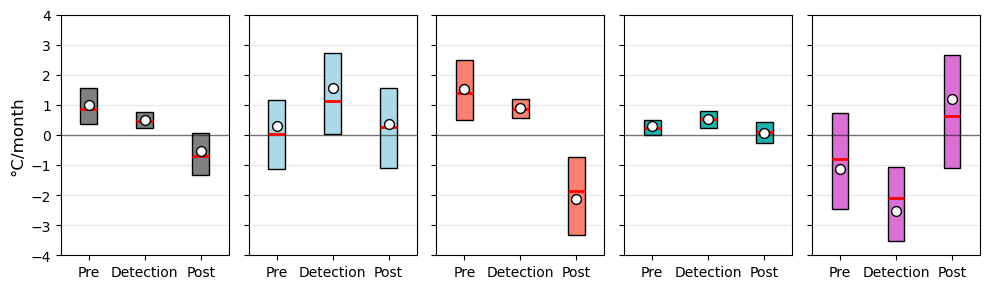

In [163]:
variables = {
    'TEND_TEMP': {
        'data': np.array(flattened_TEND_TEMP_data),
        'values': np.nanmean(flattened_TEND_TEMP_data, axis=0),
        'color': 'grey'
    },
    'TOT_ADV': {
        'data': np.array(flattened_TOTADV_data),
        'values': np.nanmean(flattened_TOTADV_data, axis=0),
        'color': 'lightblue'
    },
    'SHF_depth': {
        'data': np.array(flattened_SHF_depth_data),
        'values': np.nanmean(flattened_SHF_depth_data, axis=0),
        'color': 'salmon'
    },
    'QSW_3D': {
        'data': np.array(flattened_QSW_3D_data),
        'values': np.nanmean(flattened_QSW_3D_data, axis=0),
        'color': 'lightseagreen'
    },
    'SUBGRID': {
        'data': np.array(flattened_Subgrid_data),
        'values': np.nanmean(flattened_Subgrid_data, axis=0),
        'color': 'orchid'
    }
}

time_periods = ["Pre", "Detection", "Post"]

# Create figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3), sharey=True)

for ax, (var_name, var_data) in zip(axes, variables.items()):
    all_data = [var_data['data'][:, i] for i in range(3)]
    
    # Create boxplot
    box = ax.boxplot(
        all_data,
        patch_artist=True,
        labels=time_periods,
        showfliers=False,
        whiskerprops={'linewidth': 0},
        medianprops={'color': 'red', 'linewidth': 2},
        positions=range(1, 4),
        capprops={'linewidth': 0},
    )
    
    # Style boxes
    for patch in box['boxes']:
        patch.set_facecolor(var_data['color'])
    
    # Add dots for each period mean
    for i, (x_pos, value) in enumerate(zip(range(1, 4), var_data['values'])):
        ax.scatter(
            x_pos,
            value,
            color='white',
            edgecolor='k',
            s=50,
            zorder=10
        )
    
    # Subplot customization
    ax.set_ylim(-4, 4)
    ax.axhline(y=0, c='k', linewidth=1, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    # ax.set_title(var_name, fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=12)

plt.tight_layout()
plt.show()

In [164]:
flattened_SHF_depth_data = [inner for outer in SHF_depth_mhw_ens_all_load for inner in outer if len(inner) == 3]
flattened_QSW_3D_data = [inner for outer in QSW_3D_mhw_ens_all for inner in outer if len(inner) == 3]
flattened_TEND_TEMP_data = [inner for outer in TEND_TEMP_mhw_ens_all for inner in outer if len(inner) == 3]
flattened_Subgrid_data = [inner for outer in Subgrid_mhw_ens_all for inner in outer if len(inner) == 3]
flattened_TOTADV_data = [inner for outer in TOTADV_mhw_ens_all for inner in outer if len(inner) == 3]


NameError: name 'SHF_depth_mhw_ens_all_load' is not defined

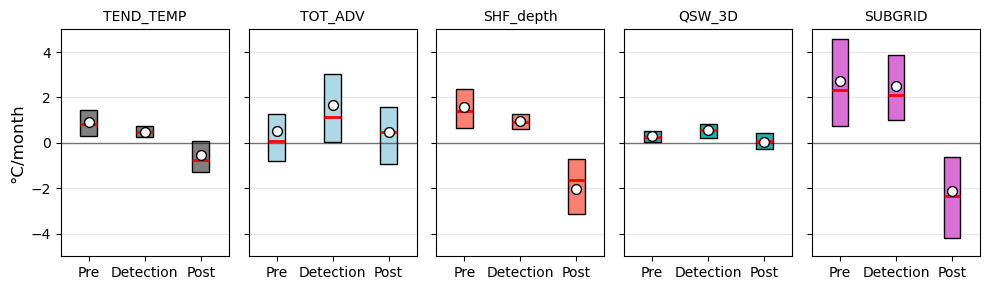

In [103]:
# Clean each dataset by removing lists with NaNs
cleaned_TEND_TEMP = [item for item in flattened_TEND_TEMP_data if not any(np.isnan(val) for val in item)]
cleaned_TOTADV = [item for item in flattened_TOTADV_data if not any(np.isnan(val) for val in item)]
cleaned_SHF = [item for item in flattened_SHF_depth_data if not any(np.isnan(val) for val in item)]
cleaned_QSW = [item for item in flattened_QSW_3D_data if not any(np.isnan(val) for val in item)]
cleaned_SUBGRID = [item for item in flattened_Subgrid_data if not any(np.isnan(val) for val in item)]

variables = {
    'TEND_TEMP': {
        'data': np.array(cleaned_TEND_TEMP),
        'values': np.mean(cleaned_TEND_TEMP, axis=0),  # [pre_mean, mid_mean, post_mean]
        'color': 'grey'
    },
    'TOT_ADV': {
        'data': np.array(cleaned_TOTADV),
        'values': np.mean(cleaned_TOTADV, axis=0),
        'color': 'lightblue'
    },
    'SHF_depth': {
        'data': np.array(cleaned_SHF),
        'values': np.mean(cleaned_SHF, axis=0),
        'color': 'salmon'
    },
    'QSW_3D': {
        'data': np.array(cleaned_QSW),
        'values': np.mean(cleaned_QSW, axis=0),
        'color': 'lightseagreen'
    },
    'SUBGRID': {
        'data': np.array(cleaned_SUBGRID),
        'values': np.mean(cleaned_SUBGRID, axis=0),
        'color': 'orchid'
    }
}

time_periods = ["Pre", "Detection", "Post"]

# Create figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3), sharey=True)

for ax, (var_name, var_data) in zip(axes, variables.items()):
    # Prepare data for all periods (transpose to get columns for each period)
    all_data = [var_data['data'][:, i] for i in range(3)]
    
    # Create boxplot
    box = ax.boxplot(
        all_data,
        patch_artist=True,
        labels=time_periods,
        showfliers=False,
        whiskerprops={'linewidth': 0},
        medianprops={'color': 'red', 'linewidth': 2},
        positions=range(1, 4),
        capprops={'linewidth': 0},      # Turn off caps (the horizontal end lines)
    )
    
    # Style boxes
    for patch in box['boxes']:
        patch.set_facecolor(var_data['color'])
    
    # Add dots for each period mean
    for i, (x_pos, value) in enumerate(zip(range(1, 4), var_data['values'])):
        ax.scatter(
            x_pos,
            value,
            color='white',
            edgecolor='k',
            s=50,
            zorder=10
        )
    
    # Subplot customization
    ax.set_ylim(-5, 5)
    ax.axhline(y=0, c='k', linewidth=1, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(var_name, fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=12)

plt.tight_layout()
plt.show()

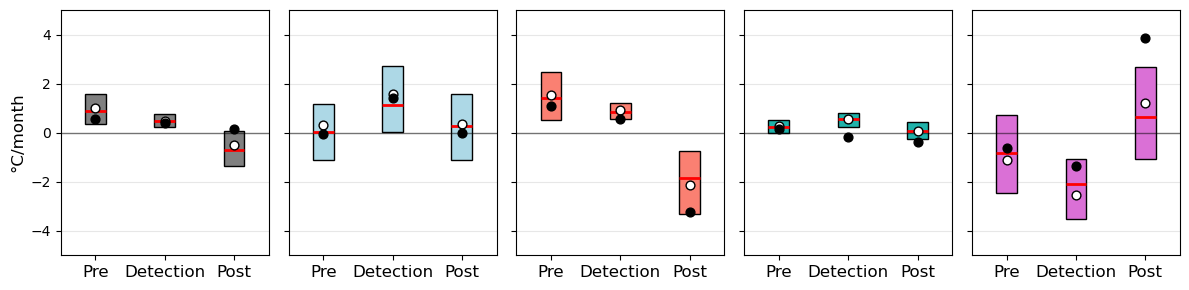

In [169]:
import numpy as np
import matplotlib.pyplot as plt

# Clean each dataset by removing lists with NaNs
cleaned_TEND_TEMP = [item for item in flattened_TEND_TEMP_data if not any(np.isnan(val) for val in item)]
cleaned_TOTADV = [item for item in flattened_TOTADV_data if not any(np.isnan(val) for val in item)]
cleaned_SHF = [item for item in flattened_SHF_depth_data if not any(np.isnan(val) for val in item)]
cleaned_QSW = [item for item in flattened_QSW_3D_data if not any(np.isnan(val) for val in item)]
cleaned_SUBGRID = [item for item in flattened_Subgrid_data if not any(np.isnan(val) for val in item)]

# Calculate ensemble means along axis 0 for each dataset
ensemble_means = {
    'TEND_TEMP': np.mean(cleaned_TEND_TEMP, axis=0),
    'TOT_ADV': np.mean(cleaned_TOTADV, axis=0),
    'SHF_depth': np.mean(cleaned_SHF, axis=0),
    'QSW_3D': np.mean(cleaned_QSW, axis=0),
    'SUBGRID': np.mean(cleaned_SUBGRID, axis=0)
}

# # FOSI values for each variable
# fosi_values = {
#     'TEND_TEMP': [1.070038976821455, 0.4074489128807234, -1.1157086197107968],
#     'TOT_ADV': [-0.5137129160330823, 1.4040671861312564, 0.2233973631232462],
#     'SHF_depth': [2.0314721315673836, 0.5375755726525471, -4.687949368341794],
#     'QSW_3D': [0.4739852616873169, -0.16682821245624094, -0.47943880036642794],
#     'SUBGRID': [-0.9217054987552405, -1.3673656355687294, 3.828282175802092]
# }

# FOSI values for each variable
fosi_values = {
    'TEND_TEMP': [0.5433970777275897, 0.4074489128807234, 0.16462527877192276],
    'TOT_ADV': [-0.050538858679528044, 1.4040671861312564, -0.033624128634393714],
    'SHF_depth': [1.0726422176759396, 0.5375755726525471, -3.2555156177332347],
    'QSW_3D': [0.1369123005768262, -0.16682821245624094, -0.3982751751676659],
    'SUBGRID': [-0.6156185794998865, -1.3673656355687294, 3.852040190587754]
}

[-0.6156185794998865, -1.3673656355687294, 3.852040190587754]

# Variables dictionary
variables = {
    'TEND_TEMP': {
        'data': np.array(cleaned_TEND_TEMP),
        'fosi': fosi_values['TEND_TEMP'],
        'ensemble': ensemble_means['TEND_TEMP'],
        'color': 'grey'
    },
    'TOT_ADV': {
        'data': np.array(cleaned_TOTADV),
        'fosi': fosi_values['TOT_ADV'],
        'ensemble': ensemble_means['TOT_ADV'],
        'color': 'lightblue'
    },
    'SHF_depth': {
        'data': np.array(cleaned_SHF),
        'fosi': fosi_values['SHF_depth'],
        'ensemble': ensemble_means['SHF_depth'],
        'color': 'salmon'
    },
    'QSW_3D': {
        'data': np.array(cleaned_QSW),
        'fosi': fosi_values['QSW_3D'],
        'ensemble': ensemble_means['QSW_3D'],
        'color': 'lightseagreen'
    },
    'SUBGRID': {
        'data': np.array(cleaned_SUBGRID),
        'fosi': fosi_values['SUBGRID'],
        'ensemble': ensemble_means['SUBGRID'],
        'color': 'orchid'
    }
}

time_periods = ["Pre", "Detection", "Post"]

# Create figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(12, 3), sharey=True)

for ax, (var_name, var_data) in zip(axes, variables.items()):
    # Prepare data for all periods
    all_data = [var_data['data'][:, i] for i in range(3)]
    
    # Create boxplot
    box = ax.boxplot(
        all_data,
        patch_artist=True,
        labels=time_periods,
        showfliers=False,
        whiskerprops={'linewidth': 0},
        capprops={'linewidth': 0},
        medianprops={'color': 'red', 'linewidth': 2},
        positions=range(1, 4)
    )
    
    # Style boxes
    for patch in box['boxes']:
        patch.set_facecolor(var_data['color'])
    
    # Add white dots for ensemble means
    for i, (x_pos, value) in enumerate(zip(range(1, 4), var_data['ensemble'])):
        ax.scatter(
            x_pos,
            value,
            color='white',
            edgecolor='k',
            s=40,
            zorder=15,
            label='Ensemble Mean' if i == 0 and var_name == 'TEND_TEMP' else ""
        )
    
    # Add teal dots for FOSI values
    for i, (x_pos, value) in enumerate(zip(range(1, 4), var_data['fosi'])):
        ax.scatter(
            x_pos,
            value,
            color='k',
            edgecolor='k',
            s=40,
            zorder=15,
            marker='o',
            label='FOSI' if i == 0 and var_name == 'TEND_TEMP' else ""
        )
    
    # Subplot customization
    ax.set_ylim(-5, 5)
    ax.axhline(y=0, c='k', linewidth=1, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    # ax.set_title(var_name, fontsize=13)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=12)
        # ax.legend(loc='upper right')

    for ax in axes:
        ax.set_xticklabels(time_periods, fontsize=12)
# for ax in axes:
        # ax.set_yticklabels([-4, -2, 0, 2, 4], fontsize=12)
# ax.tick_params(axis='y', labelsize=14, zorder=100)
plt.tight_layout()

plt.show()

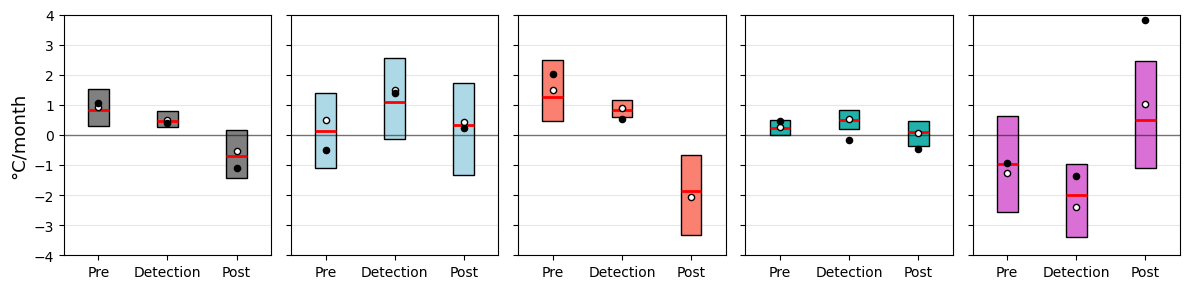

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# Clean each dataset by removing lists with NaNs
cleaned_TEND_TEMP = [item for item in flattened_TEND_TEMP_data if not any(np.isnan(val) for val in item)]
cleaned_TOTADV = [item for item in flattened_TOTADV_data if not any(np.isnan(val) for val in item)]
cleaned_SHF = [item for item in flattened_SHF_depth_data if not any(np.isnan(val) for val in item)]
cleaned_QSW = [item for item in flattened_QSW_3D_data if not any(np.isnan(val) for val in item)]
cleaned_SUBGRID = [item for item in flattened_Subgrid_data if not any(np.isnan(val) for val in item)]

# Calculate ensemble means along axis 0 for each dataset
ensemble_means = {
    'TEND_TEMP': np.mean(cleaned_TEND_TEMP, axis=0),
    'TOT_ADV': np.mean(cleaned_TOTADV, axis=0),
    'SHF_depth': np.mean(cleaned_SHF, axis=0),
    'QSW_3D': np.mean(cleaned_QSW, axis=0),
    'SUBGRID': np.mean(cleaned_SUBGRID, axis=0)
}

# FOSI values for each variable
fosi_values = {
    'TEND_TEMP': [1.070038976821455, 0.4074489128807234, -1.1157086197107968],
    'TOT_ADV': [-0.5137129160330823, 1.4040671861312564, 0.2233973631232462],
    'SHF_depth': [2.0314721315673836, 0.5375755726525471, -4.687949368341794],
    'QSW_3D': [0.4739852616873169, -0.16682821245624094, -0.47943880036642794],
    'SUBGRID': [-0.9217054987552405, -1.3673656355687294, 3.828282175802092]
}


# Variables dictionary
variables = {
    'TEND_TEMP': {
        'data': np.array(cleaned_TEND_TEMP),
        'fosi': fosi_values['TEND_TEMP'],
        'ensemble': ensemble_means['TEND_TEMP'],
        'color': 'grey'
    },
    'TOT_ADV': {
        'data': np.array(cleaned_TOTADV),
        'fosi': fosi_values['TOT_ADV'],
        'ensemble': ensemble_means['TOT_ADV'],
        'color': 'lightblue'
    },
    'SHF_depth': {
        'data': np.array(cleaned_SHF),
        'fosi': fosi_values['SHF_depth'],
        'ensemble': ensemble_means['SHF_depth'],
        'color': 'salmon'
    },
    'QSW_3D': {
        'data': np.array(cleaned_QSW),
        'fosi': fosi_values['QSW_3D'],
        'ensemble': ensemble_means['QSW_3D'],
        'color': 'lightseagreen'
    },
    'SUBGRID': {
        'data': np.array(cleaned_SUBGRID),
        'fosi': fosi_values['SUBGRID'],
        'ensemble': ensemble_means['SUBGRID'],
        'color': 'orchid'
    }
}

time_periods = ["Pre", "Detection", "Post"]

# Create figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(12, 3), sharey=True)

for ax, (var_name, var_data) in zip(axes, variables.items()):
    # Prepare data for all periods
    all_data = [var_data['data'][:, i] for i in range(3)]
    
    # Create boxplot
    box = ax.boxplot(
        all_data,
        patch_artist=True,
        labels=time_periods,
        showfliers=False,
        whiskerprops={'linewidth': 0},
        capprops={'linewidth': 0},
        medianprops={'color': 'red', 'linewidth': 2},
        positions=range(1, 4)
    )
    
    # Style boxes
    for patch in box['boxes']:
        patch.set_facecolor(var_data['color'])
    
    # Add white dots for ensemble means
    for i, (x_pos, value) in enumerate(zip(range(1, 4), var_data['ensemble'])):
        ax.scatter(
            x_pos,
            value,
            color='white',
            edgecolor='k',
            s=20,
            zorder=10,
            label='Ensemble Mean' if i == 0 and var_name == 'TEND_TEMP' else ""
        )
    
    # Add teal dots for FOSI values
    for i, (x_pos, value) in enumerate(zip(range(1, 4), var_data['fosi'])):
        ax.scatter(
            x_pos,
            value,
            color='k',
            edgecolor='k',
            s=20,
            zorder=10,
            marker='o',
            label='FOSI' if i == 0 and var_name == 'TEND_TEMP' else ""
        )
    
    # Subplot customization
    ax.set_ylim(-4., 4.)
    ax.axhline(y=0, c='k', linewidth=1, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    # ax.set_title(var_name, fontsize=13)
    if ax == axes[0]:
        ax.set_ylabel('°C/month', fontsize=13)
        # ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [165]:
fosi_heat_budget = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_heat_budget_155m.nc')